In [32]:
# V4: dune toe based on curvature (x_toe), slope (x_toe2, x_toe3) with temporal smoothing before toe extraction (x_toe, x_toe2) and after (x_toe3) 
# v5: temporal filtering to remove noise, except when slumping occured

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.collections import LineCollection
import colorcet as cc   # For color maps
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [33]:
## 1) FUNCTION TO LOAD AND FILTER LIDAR DATA
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None, i_obs_start=361, i_obs_end=545):
    # Load pointcloud and convert to local coordinates. Filter cloud by deleting the mounting frame from the cloud, as well as high points that are waves/rain/...  
    # i_obs_start = 361  is straight under the lidar. i_obs_start = 545 for the later storms, when the dune toe is further seaward. i_obs_end = 545 # for 93deg

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3) for 3 skip_regions × 2 limits (start_stop) × 4 lidars × 3 storms
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

        # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
        # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

        # # # find obs_number with -90° < beam_angle < 105°
        # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
        # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
        # print(i_obs_end)



    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordinate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=True, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)
    ds['intensity'] = ds.intensity.where(mask_keep)

    return ds


In [34]:
def filtered_mean_remove_smallest(windows, std_thr=0.01, min_keep_frac=0.5):
    """
    Remove smallest values iteratively (per window along last axis) until std <= std_thr.
    Return mean of remaining values; return NaN if too many values were removed.

    Parameters
    ----------
    windows : np.ndarray
        Any shape (..., L). Filtering is done along the last axis only.
    std_thr : float
        Threshold for population std (ddof=0), e.g. 0.01.
    min_keep_frac : float
        Minimum fraction of values that must remain. If fewer remain, output NaN.

    Returns
    -------
    out : np.ndarray
        Shape windows.shape[:-1], containing filtered means.
    """

    # NB: effectively a faster, vectorized version of this loop-based approach:
    # r_filter_v2 = r_mean_5s.copy()
    # for i in range(n_obs):
    #     for j in range(n_win):
    #         window = windows[i, j, :].copy()
    #         while np.nanstd(window) > 0.01 and np.count_nonzero(~np.isnan(window)) > 0:
    #             # remove the smallest (non-NaN) value
    #             try:
    #                 idx_to_remove = np.nanargmin(window)
    #             except ValueError:
    #                 break
    #             window[idx_to_remove] = np.nan
    #         r_filter_v2[i, j] = np.nanmean(window)

    #         if np.count_nonzero(~np.isnan(window)) < win_len / 2:
    #             r_filter_v2[i, j] = np.nan
    
    W0 = np.asarray(windows, dtype=float)
    if W0.ndim < 1:
        raise ValueError("`windows` must have at least 1 dimension.")

    L = W0.shape[-1]
    leading_shape = W0.shape[:-1]
    N = int(np.prod(leading_shape)) if leading_shape else 1

    # Flatten only leading dims; keep last dim as window length
    W = W0.reshape(N, L)

    valid = np.isfinite(W)
    n_valid = valid.sum(axis=1)

    # Sort once per window; NaNs -> +inf so they move to the end
    W_sort = np.sort(np.where(valid, W, np.inf), axis=1)
    finite_sorted = np.isfinite(W_sort)
    X = np.where(finite_sorted, W_sort, 0.0)

    # Prefix sums (with leading zero)
    cs = np.concatenate([np.zeros((N, 1)), np.cumsum(X, axis=1)], axis=1)
    cs2 = np.concatenate([np.zeros((N, 1)), np.cumsum(X * X, axis=1)], axis=1)

    total = cs[:, -1]
    total2 = cs2[:, -1]

    # k = number of removed smallest values
    k = np.arange(L + 1)[None, :]      # (1, L+1)
    m = n_valid[:, None] - k           # remaining count after removing k smallest

    # Remaining sums after removing k smallest values
    sum_rem = total[:, None] - cs[:, :L+1]
    sumsq_rem = total2[:, None] - cs2[:, :L+1]

    with np.errstate(invalid="ignore", divide="ignore"):
        mean_rem = sum_rem / m
        var_rem = sumsq_rem / m - mean_rem * mean_rem
    std_rem = np.sqrt(np.maximum(var_rem, 0.0))

    min_keep = int(np.ceil(min_keep_frac * L))
    good = (m >= min_keep) & np.isfinite(std_rem) & (std_rem <= std_thr)

    has_solution = good.any(axis=1)
    k_star = np.where(has_solution, good.argmax(axis=1), -1)

    out = np.full(N, np.nan, dtype=float)
    rows = np.where(has_solution)[0]
    out[rows] = mean_rem[rows, k_star[rows]]

    return out.reshape(leading_shape)

In [35]:
## 2) LOAD AND FILTER LIDAR DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 1  # set as needed (1-based, like MATLAB)
i_obs_start_all = [420, 500, 420] # for 3 storms
for n_storm in [2]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 02:02') # was 2:00
        t2 = pd.Timestamp('19-12-2024 22:00') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:10')
        # t1 = pd.Timestamp('22-12-2024 16:30')
        # t2 = pd.Timestamp('22-12-2024 20:00')
        # t1 = pd.Timestamp('22-12-2024 07:00')
        # t2 = pd.Timestamp('22-12-2024 10:30')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    i_obs_start = i_obs_start_all[n_storm-1] # Python: 0-based indexing
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2, i_obs_start=i_obs_start ) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)    
    #ds = ds.drop_vars(['x','z'])



In [36]:
# MAKE T SPACING EXACTLY 0.25S ------------------------------------------------------------------------------------------
# Times are snapped to the nearest 0.25s, times without nearby value get nan. No interpolation/resampling is done. So timeseries get distorted slightly, but that does not matter for profiles, where we look at moving averages etc anyway. 
t = pd.to_datetime(ds.t.values)                                                         # original time values
t_new = pd.date_range(t.min().ceil("250ms"), t.max().floor("250ms"), freq="250ms")      # uniform time grid with 0.25s spacing
idx = pd.Index(t_new).get_indexer(t, method="nearest")                                  # Compute nearest indices for t on target grid

r_new = xr.DataArray( np.full((ds.sizes["obs_number"], len(t_new)), np.nan),            # build empty array for r with uniform time spacing
                      dims=("obs_number", "t"),
                      coords={"obs_number": ds.obs_number, "t": t_new}   )
r_new.values[:, idx] = ds.radius_lidar.values                                           # fill. If collisions happen, later ones overwrite earlier ones
I_new = xr.DataArray( np.full((ds.sizes["obs_number"], len(t_new)), np.nan),            # build empty array for I with uniform time spacing
                      dims=("obs_number", "t"),
                      coords={"obs_number": ds.obs_number, "t": t_new}   )
I_new.values[:, idx] = ds.intensity.values                                           # fill. If collisions happen, later ones overwrite earlier ones

# update ds in-place
ds = ds.drop_dims("t")
ds = ds.assign_coords(t=t_new)
ds["radius_lidar"] = r_new
ds["intensity"] = I_new

ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=False, keep_I=True, keep_r=True, keep_y=False) # Recalculate x, z. Effectively the same as updating x and z with the new t-coordinate. 

In [37]:
## FILTER OVER 5s WINDOW

# Settings ------------------------------------------------------------------------------------------------------
sf = float(ds.sf.values)
if sf != 4.0:   # Temp code: sampling frequency of storm 2, lidar 2 is incorrect, at 0.1 Hz instead of 4 Hz
    warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")
    sf = 4
win_len = int(5 * sf)   # 5s in samples
step = int(5 * sf)      # 5s in samples

# Build strided window view of r, for fast computation of percentiles over the windows.---------------------------
#r = ds.radius_lidar.transpose("obs_number", "t")  # ensure shape is (obs_number, t)
arr = ds.radius_lidar.values
n_obs, n_t = arr.shape

# number of windows
n_win = (n_t - win_len) // step + 1
if n_win <= 0:
    raise ValueError("Not enough samples for a 10-min window.")

# build strided window view: (obs_number, window, sample)
s0, s1 = arr.strides
windows = np.lib.stride_tricks.as_strided( arr,
                                           shape=(n_obs, n_win, win_len),
                                           strides=(s0, step * s1, s1),
                                           writeable=False )

# Calculate the median and standard deviation over the window samples
r_mean_5s = np.mean(windows, axis=2)  # shape (obs_number, n_win)
r_std_5s = np.std(windows, axis=2)     # shape (obs_number, n_win)

# filter v2: if std>1cm, iteratively remove smallest r until std<1cm. If 50% of values are removed, r_filtered=NaN
r_filter_v2 = filtered_mean_remove_smallest(windows, std_thr=0.01, min_keep_frac=0.5)

# calculate filtered I
arr = ds.intensity.values
s0, s1 = arr.strides
windows = np.lib.stride_tricks.as_strided( arr,
                                           shape=(n_obs, n_win, win_len),
                                           strides=(s0, step * s1, s1),
                                           writeable=False )
I_filter_v2 = np.nanmean(windows, axis=2)  # shape (obs_number, n_win)       # WARNING: SIMPLIFIED ************************* 
I_filter_v2[np.isnan(r_filter_v2)] = np.nan

# Assign back to ds -----------------------------------------------------------------------------------------
# center times for each window
t_vals = pd.to_datetime(ds.t.values)
center_idx = np.arange(n_win) * step + win_len // 2
t_center = t_vals[center_idx].round('0.5s')  

# wrap back to xarray
r_filter_v2 = xr.DataArray( r_filter_v2,  dims=("obs_number", "t"),  coords={"obs_number": ds.obs_number, "t": t_center}  )
I_filter_v2 = xr.DataArray( I_filter_v2,  dims=("obs_number", "t"),  coords={"obs_number": ds.obs_number, "t": t_center}  )

# Save result to Xarray Dataset --------
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_filter_v2 = ds.drop_dims("t")  # drop t dimension

ds_filter_v2['radius_lidar'] = r_filter_v2  # Assign r_final as the new radius_lidar. Var name must be radius_lidar for convert_lidar_coordinates_ds
ds_filter_v2['intensity'] = I_filter_v2      # WARNING: INTENSITY BASED ON FULL WINDOW, NO ITERATION APPLIED *******************

ds_filter_v2 = convert_lidar_coordinates_ds(ds_filter_v2, 'local', max_echos=False, keep_I=True, keep_r=True, keep_y=False) # skip intensity. Max echos already taken, not needed again

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_4452\2698399925.py:42: RuntimeWarning: Mean of empty slice
  I_filter_v2 = np.nanmean(windows, axis=2)  # shape (obs_number, n_win)       # WARNING: SIMPLIFIED *************************


In [38]:
# Filter v3: remove all profiles where 
# - the first nonnan value of x > 792 or 796
# - the largest difference dL (dx^2 + dz^2)^(1/2) between consecutive points exceeds 0.5 m
ds_filter_v3 = ds_filter_v2.copy(deep=True)
dL_max = 1

# settings
if n_storm == 1:
    x_min = 792
else:
    x_min = 796


for i in range(n_win):
    x = ds_filter_v3.x.values[:, i]  # shape (obs_number,)
    z = ds_filter_v3.z.values[:, i]  # shape (obs_number,)

    # extract non_nan values
    non_nan_mask = ~np.isnan(x) & ~np.isnan(z)
    x_non_nan = x[non_nan_mask]
    z_non_nan = z[non_nan_mask]

    if len(x_non_nan) == 0:
        continue
    if x_non_nan[0] > x_min:
        ds_filter_v3.radius_lidar.values[:, i] = np.nan
        ds_filter_v3.x.values[:, i] = np.nan
        ds_filter_v3.z.values[:, i] = np.nan
        ds_filter_v3.intensity.values[:, i] = np.nan
        continue

    mask_keep = (x_non_nan > x_min) & (z_non_nan < 4.5)  # keep points that are landward of 796 and below the crest
    mask_keep[:-1] |= mask_keep[1:]       # set previous neighbour true where next is true: keep last point before x=796
    mask_keep[1:]  |= mask_keep[:-1]      # set next neighbour true where previous is true: keep last point after z=4.5

    z_region_of_interest = z_non_nan[mask_keep]  # extract landward points
    x_region_of_interest = x_non_nan[mask_keep]  # extract landward points
    dL = np.sqrt(np.diff(x_region_of_interest)**2 + np.diff(z_region_of_interest)**2)
    if np.max(dL) > dL_max:
        ds_filter_v3.radius_lidar.values[:, i] = np.nan
        ds_filter_v3.x.values[:, i] = np.nan
        ds_filter_v3.z.values[:, i] = np.nan
        ds_filter_v3.intensity.values[:, i] = np.nan
        continue

In [39]:
# NEW RESAMPING: SELECT ONLY NON-NAN OBSERVATIONS
def resample_nearest_non_nan(ds_in, valid_var="x", vars_2d=None, dt=np.timedelta64(30, "s"), max_gap=None):
    """
    Resample along time by picking, for each obs_number, the nearest timestamp
    where valid_var is non-NaN.
    """
    if vars_2d is None:
        vars_2d = [valid_var, "z", "radius_lidar", "intensity"]

    if valid_var not in ds_in:
        raise ValueError(f"Variable '{valid_var}' not found in dataset.")

    # source times
    source_time = ds_in.t.values.astype("datetime64[ns]")      # original time stamps
    source_time_ns = source_time.astype(np.int64)              # same times in integer ns (fast distance math)

    # target regular time grid
    start_time = source_time[0]                                # first source timestamp
    end_time = source_time[-1]                                 # last source timestamp
    target_time = np.arange(start_time, end_time + dt, dt)     # regular output grid
    target_time_ns = target_time.astype(np.int64)              # target times in integer ns

    # mask of valid points for selection variable
    valid_mask = np.isfinite(ds_in[valid_var].values)          # shape: (obs_number, t)
    n_obs = valid_mask.shape[0]                                # number of obs_number rows
    n_target = target_time.size                                # number of target timestamps

    # selected source index per (obs_number, target_time); -1 means no valid match
    selected_src_idx = np.full((n_obs, n_target), -1, dtype=int)

    # choose nearest valid source time for each obs_number independently
    for obs_idx in range(n_obs):
        valid_source_idx = np.flatnonzero(valid_mask[obs_idx])         # source t-indices where valid_var is finite
        if valid_source_idx.size == 0:
            continue

        valid_source_time_ns = source_time_ns[valid_source_idx]        # valid source times for this obs row
        insert_pos = np.searchsorted(valid_source_time_ns, target_time_ns, side="left")

        left_pos = np.clip(insert_pos - 1, 0, valid_source_idx.size - 1)
        right_pos = np.clip(insert_pos, 0, valid_source_idx.size - 1)

        dist_left = np.abs(target_time_ns - valid_source_time_ns[left_pos])
        dist_right = np.abs(valid_source_time_ns[right_pos] - target_time_ns)

        choose_right = dist_right < dist_left
        chosen_pos = np.where(choose_right, right_pos, left_pos)

        selected_src_idx[obs_idx, :] = valid_source_idx[chosen_pos]

    # optional: reject matches that are too far away in time
    if max_gap is not None:
        max_gap_ns = pd.to_timedelta(max_gap).to_timedelta64().astype("timedelta64[ns]").astype(np.int64)
        valid_pick = selected_src_idx >= 0
        row_idx, col_idx = np.where(valid_pick)
        picked_dist_ns = np.abs(source_time_ns[selected_src_idx[row_idx, col_idx]] - target_time_ns[col_idx])

        too_far = picked_dist_ns > max_gap_ns
        selected_src_idx[row_idx[too_far], col_idx[too_far]] = -1

    # build output dataset on target grid
    ds_out = ds_in.drop_dims("t").assign_coords(t=target_time)

    # copy selected values into output variables
    for var_name in vars_2d:
        if var_name not in ds_in:
            continue

        var_data = ds_in[var_name]
        if tuple(var_data.dims) != ("obs_number", "t"):
            continue

        out_values = np.full((n_obs, n_target), np.nan, dtype=float)   # output array for this variable
        valid_pick = selected_src_idx >= 0
        row_idx, col_idx = np.where(valid_pick)
        out_values[row_idx, col_idx] = var_data.values[row_idx, selected_src_idx[row_idx, col_idx]]

        ds_out[var_name] = (("obs_number", "t"), out_values)

    return ds_out, selected_src_idx


# Run resampling: nearest non-NaN x per obs_number on a 30 s grid
ds_filter_v3_30s, src_idx_30s = resample_nearest_non_nan(
    ds_in=ds_filter_v3,
    valid_var="x",
    vars_2d=["x", "z", "radius_lidar", "intensity"],
    dt=np.timedelta64(30, "s"),
    #max_gap=np.timedelta64(60, "s") )  # set to None if you do not want a distance limit
    max_gap=None )

In [40]:
#  TOE ESTIMATION BASED ON SLOPE

# Estimate toe location: Find location of maximum curvature along each profile. based on 10min windows
# Settings ---------------------------------------------------------------------------------------
x_vals = ds_filter_v3_30s.x.values
z_vals = ds_filter_v3_30s.z.values

minutes_smoothing = 5#10  # in minutes, for Gaussian smoothing over time. Set to 0 to skip 
dt_minutes = 0.5 # time step between profiles

# Define elevation range for toe search [m NAP]
z_min_toe = 1.8 #2.0   # storm 1
z_max_toe = 3.5
#z_max_toe = z_max_toe_all[n_storm-1] # Python: 0-based indexing
x_max_crest = 801
if n_storm > 3:
    # give error: check x_max_crest, may be >801 for sandy dune
    raise ValueError("crest estimation: check x_max_crest, may be >801 for sandy dune. ")

# Target spacing along the arc length [m]
dl_target = 0.05 # [m]
dl_smoothing = 0.2 # for Gaussian smoothing over space, after profile is interpolated.  [m]

dl_window = 1.0 # window size in arc length [m], to check if slope > slope limit over that window. 
if n_lidar == 3:
    slope_limit = 15 # for dike, which has no real cliff, use a lower slope
else:
    slope_limit = 20# slope limit for slope-based toe estimation. [deg]  (20° = 1:2.8)

# Function definion ---------------------------------------------------------------------------------------
# Define fucntion to resample a single profile for roughly constant spacing along its arc length, remove overhang and smooth
def resample_profile(x_profile, z_profile, dl_target, dl_smoothing, remove_overhang=False):
    """Interpolate the profile so points are roughly dl_target apart along the curve."""
    valid_mask = ~(np.isnan(x_profile) | np.isnan(z_profile))
    if valid_mask.sum() < 3:
        return None

    # Keep only valid points and compute cumulative arc length
    x_valid = x_profile[valid_mask]
    z_valid = z_profile[valid_mask]

    # Optional: remove overhang
    if remove_overhang:
        # remove overhang: x_min is mininum of all following values. 
        x_min = np.minimum.accumulate(x_valid[::-1])[::-1]
        x_valid = x_min

        # # select only x and z with x >=x_min
        # x_max = np.maximum.accumulate(x_valid) # max of all previous values
        # z_valid = z_valid[x_valid >= x_max]
        # x_valid = x_valid[x_valid >= x_max]

    tangential_diffs = np.sqrt(np.diff(x_valid)**2 + np.diff(z_valid)**2)
    if tangential_diffs.size == 0:
        return None

    s_profile = np.concatenate(([0.0], np.cumsum(tangential_diffs)))
    total_length = s_profile[-1]
    if total_length <= 0:
        return None

    # Create a uniform grid along the arc length
    n_target = max(int(np.ceil(total_length / dl_target)) + 1, 3)
    s_uniform = np.linspace(0.0, total_length, n_target)

    # Interpolate x/z as functions of arc length
    x_interp = np.interp(s_uniform, s_profile, x_valid)
    z_interp = np.interp(s_uniform, s_profile, z_valid)
    ds_step = s_uniform[1] - s_uniform[0]

    # Optional Gaussian smoothing along the arc length
    if dl_smoothing is not None and dl_smoothing > 0:
        sigma_samples = dl_smoothing / ds_step
        z_interp = gaussian_filter1d(z_interp, sigma=sigma_samples, mode='nearest')

    return x_interp, z_interp, ds_step

def extract_toe_cliff(x, z, z_min_toe, z_max_toe, x_max_crest, dl_window, slope_limit):
    # Compute slope in degrees
    slope = np.arctan(np.gradient(z, x)) * 180 / np.pi  # find slope
    
    # mask 1: points where slope exceeds 'slope_limit' degrees
    mask1 = slope > slope_limit

    # mask 2: points where slope exceeds 'slope_limit' degrees over a window (in arc length)
    di_window = int(dl_window / ds_step)
    dx = x[di_window:] - x[:-di_window]
    dz = z[di_window:] - z[:-di_window]
    slope_window = np.arctan(dz / dx) * 180 / np.pi
    mask2 = np.concatenate([slope_window > slope_limit, np.full(di_window, False)])   # Over the next i cells, slope>slope_limit. Pad the end with False to maintain length
    mask2b = np.concatenate([np.full(di_window, False), slope_window > slope_limit])  # mask 2b: same as mask 2, but backward. pad the beginning with False

    # mask 3: in the target elevation range
    mask_range_toe = (z >= z_min_toe) & (z <= z_max_toe)

    # mask 4: in the target x-range
    mask_range_crest = (x <= x_max_crest)

    # find x_toe, z_toe: first point where all masks are true
    mask_combined_toe = mask1 & mask2 & mask_range_toe
    if not np.any(mask_combined_toe):
        return None
    idx_toe = np.argmax(mask_combined_toe)  # index of first True value
    x_toe = x[idx_toe]
    z_toe = z[idx_toe]

    mask_combined_crest = mask1 & mask2b & mask_range_crest
    # idx_crest: index of the last True value
    if np.any(mask_combined_crest):
        idx_crest = np.where(mask_combined_crest)[0][-1]  # index of last True value
        x_crest = x[idx_crest]
        z_crest = z[idx_crest]
    else:
        x_crest = np.nan
        z_crest = np.nan

    return x_toe, z_toe, x_crest, z_crest

# Calculation ---------------------------------------------------------------------------------------
# Prepare arrays to store toe estimates for each minute
n_timesteps = x_vals.shape[1]
x_toe = np.full(n_timesteps, np.nan)
z_toe = np.full(n_timesteps, np.nan)
x_crest = np.full(n_timesteps, np.nan)
z_crest = np.full(n_timesteps, np.nan)


# Loop over every profile and resample it to find the curvature peak inside the target elevation range
for minute_idx in range(n_timesteps):
    # Resample and smooth the profile along its arc length, to get constant spacing and reduce noise
    resampled = resample_profile(x_vals[:, minute_idx], z_vals[:, minute_idx], dl_target, dl_smoothing, remove_overhang=True)
    if resampled is None:
        continue
    x_interp, z_interp, ds_step = resampled

    # Resample and smooth the profile for this minute, and extract the toe based on curvature    
    toe = extract_toe_cliff(x_interp, z_interp, z_min_toe, z_max_toe, x_max_crest, dl_window, slope_limit)
    if toe is None:
        continue
    x_toe[minute_idx], z_toe[minute_idx], x_crest[minute_idx], z_crest[minute_idx] = toe

# Smooth the profiles over time using a Gaussian filter
sigma_samples = minutes_smoothing / dt_minutes  # convert smoothing width from minutes to number of samples
if sigma_samples > 0:
    x_toe = gaussian_filter1d(x_toe, sigma=sigma_samples, mode='nearest')
    z_toe = gaussian_filter1d(z_toe, sigma=sigma_samples, mode='nearest')
    x_crest = gaussian_filter1d(x_crest, sigma=sigma_samples, mode='nearest')
    z_crest = gaussian_filter1d(z_crest, sigma=sigma_samples, mode='nearest')

# Store the new toe time series in the 30s dataset and full dataset
ds_filter_v3_30s["x_toe"] = ("t", x_toe)
ds_filter_v3_30s["z_toe"] = ("t", z_toe)
ds_filter_v3_30s["x_crest"] = ("t", x_crest)
ds_filter_v3_30s["z_crest"] = ("t", z_crest)

t_old = ds_filter_v3.t.values
x_toe_old = ds_filter_v3_30s.x_toe.sel(t=t_old, method="nearest").values
z_toe_old = ds_filter_v3_30s.z_toe.sel(t=t_old, method="nearest").values
x_crest_old = ds_filter_v3_30s.x_crest.sel(t=t_old, method="nearest").values
z_crest_old = ds_filter_v3_30s.z_crest.sel(t=t_old, method="nearest").values

ds_filter_v3["x_toe"] = ("t", x_toe_old)
ds_filter_v3["z_toe"] = ("t", z_toe_old)
ds_filter_v3["x_crest"] = ("t", x_crest_old)
ds_filter_v3["z_crest"] = ("t", z_crest_old)

c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * 

np.float64(2.8020377567722567)

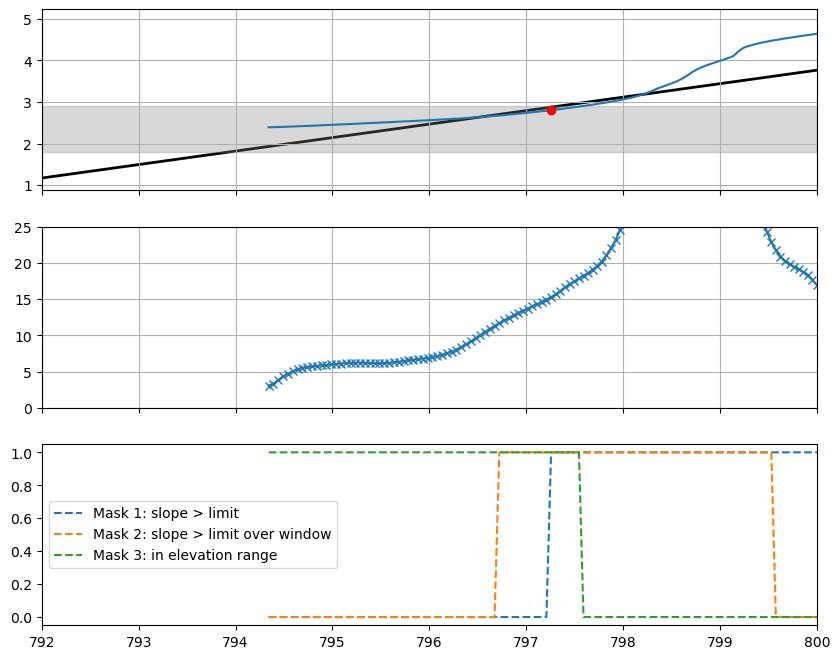

In [41]:
# Plot specific timestep: profile, slope and masks
minute_idx = 0#2500
x_vals = ds_filter_v3_30s.x.values
z_vals = ds_filter_v3_30s.z.values
resampled = resample_profile(x_vals[:, minute_idx], z_vals[:, minute_idx], dl_target, dl_smoothing, remove_overhang=True)
x_interp, z_interp, ds_step = resampled

x = x_interp
z = z_interp
slope_limit = 15
z_max_toe = 2.9 # 2.9
slope = np.arctan(np.gradient(z_interp, x_interp)) * 180 / np.pi

# Plot data
x_construction = np.array([803.11, 791.69])
z_construction = np.array([  4.77,   1.07])#-0.204 # shift 4 cm, to put top instead of center of line at y

# mask 1: points where slope exceeds 'slope_limit' degrees
mask1 = slope > slope_limit

# mask 2: points where slope exceeds 'slope_limit' degrees over a window (in arc length)
di_window = int(dl_window / ds_step)
dx = x[di_window:] - x[:-di_window]
dz = z[di_window:] - z[:-di_window]
slope_window = np.arctan(dz / dx) * 180 / np.pi
mask2 = np.concatenate([slope_window > slope_limit, np.full(di_window, False)])  # pad the end with False to maintain length

# mask 3: in the target elevation range
mask_range = (z >= z_min_toe) & (z <= z_max_toe)

# find x_toe, z_toe: first point where all masks are true
mask_combined = mask1 & mask2 & mask_range
if not np.any(mask_combined):
    warnings.warn("No point found that satisfies all conditions for toe estimation.")
idx_toe = np.argmax(mask_combined)  # index of first True value
x_toe = x[idx_toe]
z_toe = z[idx_toe]


# plot x_interp vs z_interp
plot, axs = plt.subplots(3,1, figsize=(10, 8), sharex=True)
axs[0].plot(x, z, label="Resampled Profile")
axs[0].plot(x_construction, z_construction, linestyle='-', color='black', linewidth=2, label='Revetment', zorder=1)  # revetment line
axs[0].axhspan(z_min_toe, z_max_toe, color='gray', alpha=0.3, label="Elevation range for toe")   # mark elevation range with gray area
axs[0].scatter(x_toe, z_toe, color='red', label="Estimated Toe", zorder=5)
axs[0].grid()



axs[1].plot(x, slope, '-x',label="Slope (deg)")
axs[1].grid()
axs[1].set_ylim([0, 25])
axs[2].plot(x, mask1, '--', label="Mask 1: slope > limit")
axs[2].plot(x, mask2, '--', label="Mask 2: slope > limit over window")
axs[2].plot(x, mask_range, '--', label="Mask 3: in elevation range")
#axs[2].plot(x, mask_combined, '--', label="Combined Mask")
axs[2].legend()
axs[2].set_xlim([792,800])
#axs[2].set_xlim([792,796])


z_toe

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_4452\3900490079.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(tick_labels)


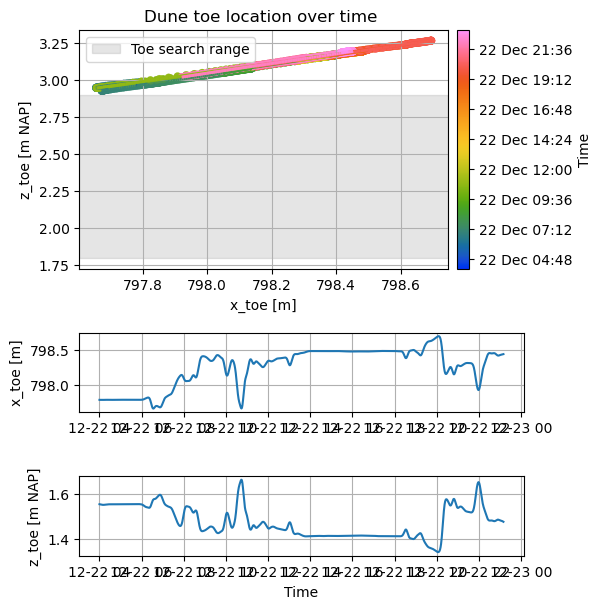

In [42]:
# Plot toe location evolution over time ------------
t1 = pd.Timestamp('19-12-2024 12:00') 
t2 = pd.Timestamp('19-12-2024 22:00') 
t1 = pd.Timestamp('22-12-2024 8:30') 
t2 = pd.Timestamp('22-12-2024 9:15') 

ds_plot = ds_filter_v3_30s#.sel(t=slice(t1,t2))

fig, axs = plt.subplots(3,1, figsize=(6, 6),     gridspec_kw={"height_ratios": [3, 1, 1]})

# Get toe coordinates and times
x_toe = ds_plot.x_toe.values
z_toe = ds_plot.z_toe.values
# use the datetime coordinate from the dataset
times = pd.to_datetime(ds_plot.t.values)

# Mask out invalid entries
valid = ~(np.isnan(x_toe) | np.isnan(z_toe)) # valid if both x_toe and z_toe are finite
if valid.sum() == 0:
    raise RuntimeError('No valid toe points to plot')

x_toe = x_toe[valid]
z_toe = z_toe[valid]
z_crest = ds_plot.z_crest.values[valid]
times = times[valid]

# Map datetimes to numeric for colormap scaling
time_nums = mdates.date2num(times)
norm = mcolors.Normalize(vmin=time_nums.min(), vmax=time_nums.max())

ax = axs[0]
# Plot colored line using LineCollection so color varies with time
points = np.array([x_toe, z_toe]).T
segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
cmap = plt.get_cmap('cet_CET_R1')
lc = LineCollection(segments, cmap=cmap, norm=norm)

# associate each segment with the time of its starting point
lc.set_array(time_nums[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)

# Scatter points colored by time
sc = ax.scatter(x_toe, z_toe, c=time_nums, cmap=cmap, norm=norm, s=30, linewidth=0.2)

# Colorbar with readable datetime labels
cb = fig.colorbar(lc, ax=ax, pad=0.02)
# convert ticks to human-readable datetimes
tick_locs = cb.get_ticks()
tick_labels = [mdates.num2date(t).strftime('%d %b %H:%M') for t in tick_locs]
cb.ax.set_yticklabels(tick_labels)
cb.set_label('Time')

# Highlight toe search range
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range')

ax.set_xlabel('x_toe [m]')
ax.set_ylabel('z_toe [m NAP]')
ax.set_title('Dune toe location over time ')
ax.grid()
ax.legend(loc='upper left')

# autoscale view to include LineCollection
ax.autoscale()
plt.tight_layout()

ax = axs[1]
ax.plot(times, x_toe, '-', label='x_toe')
ax.set_ylabel('x_toe [m]')
ax.grid()

ax = axs[2]
ax.plot(times, z_crest - z_toe, '-', label='z_toe')
ax.set_xlabel('Time')
ax.set_ylabel('z_toe [m NAP]')
ax.grid()
folder = r"C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Data experiment\Figures Lidar\Dune profiles, toe"
filename = f"Smoothed toe evolution S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=300)

plt.show()

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(times, z_toe, '-o', label='z_toe')

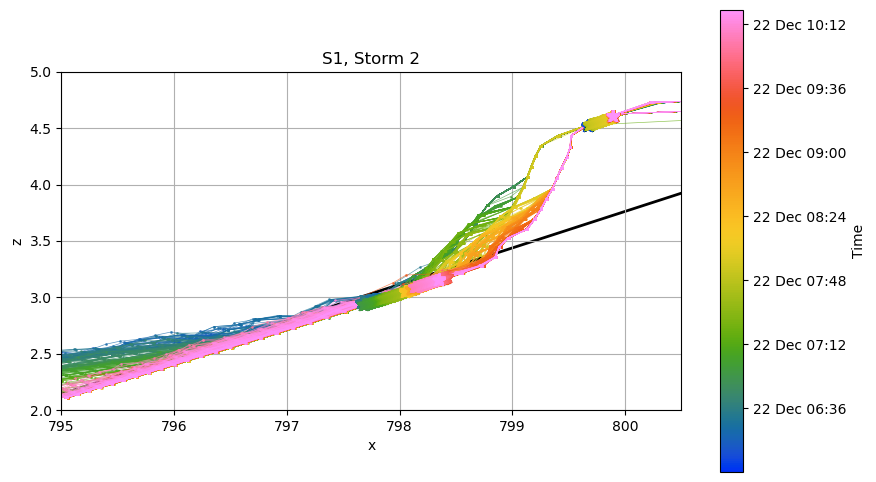

In [43]:
#t1 = pd.Timestamp('19-12-2024 04:00') 
#t2 = pd.Timestamp('19-12-2024 20:00') 
t1 = pd.Timestamp('2024-12-19 18:45') 
t2 = pd.Timestamp('2024-12-19 18:59') 
t1 = pd.Timestamp('2024-12-22 6:00') 
t2 = pd.Timestamp('2024-12-22 10:20') 
#t1 = np.datetime64('2025-01-01T15:00')
#t2 = np.datetime64('2025-01-01T16:00')

ds_plot = ds_filter_v3.sel(t=slice(t1, t2))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t']
step = max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))
x_prev = None

# plot lines on ax 
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    if x_prev is not None:
        if np.nanmax(np.abs(x[mask] - x_prev[mask])) < 0.01:  # skip profiles almost identical to previous one, ignoring NaNs
            continue

    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)
    x_prev = x.copy()
    z_prev = z.copy()

for j in range(0, n_steps, step):
    color = cmap(norm(times_num[j]))
    ax.plot(ds_plot.x_toe.values[j], ds_plot.z_toe.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    ax.plot(ds_plot.x_crest.values[j], ds_plot.z_crest.values[j], '*', markersize=9, color=color)  # plot crest location for this profile

ax.plot(x_construction, z_construction, linestyle='-', color='black', linewidth=2, label='Revetment', zorder=1)  # revetment line


# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([795, 800.5])
ax.set_ylim([2, 5])
# ax.set_xlim([796, 798.8])
# ax.set_ylim([2.2, 4.5])


ax.grid()
ax.set_aspect('equal', adjustable='box')
ax.set_title(f"S{n_lidar}, Storm {n_storm}")

filename = f"Dune profiles with toe -  S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=200)

plt.show()


In [14]:
# DETERMINE CLIFF EROSION
# Keep only timesteps where not all x are nan
t_keep = ds_filter_v3.t.values[~np.isnan(ds_filter_v3.x.values).all(axis=0)]
ds = ds_filter_v3.sel(t=t_keep)

# t1 = pd.Timestamp('19-12-2024 8:27') # was 2:00
# t2 = pd.Timestamp('19-12-2024 8:28') # was 19dec 22:00
x = ds.x#.sel(minute=slice(t1,t2))  # dims: (obs_number, minute)
z = ds.z#.sel(minute=slice(t1,t2))  # dims: (obs_number, minute)

# fill nans in x and z with linear interpolation in t, over gaps of max 2 minutes
x = x.interpolate_na(dim="t", method="linear", max_gap=pd.Timedelta("2min"))
z = z.interpolate_na(dim="t", method="linear", max_gap=pd.Timedelta("2min"))

# Settings ---------------------------------------------------------------------------------------
# z_min = 3.5 # instead use dune toe + x m
z_max = 4.5
x_right = 810.0

areas = []
erosion_volumes = []
# erosion_volumes_toe30 = []
# erosion_volumes_toe50 = []
# erosion_volumes_toe70 = []
minutes_area = []

# function definitions ---------------------------------------------------------------------------------------
def polygon_area(x_coords, z_coords):
    """Calculate polygon area using shoelace formula"""
    return 0.5 * np.abs(np.dot(x_coords, np.roll(z_coords, 1)) -
                        np.dot(z_coords, np.roll(x_coords, 1)))

def linear_interp(z1, x1, z2, x2, z_target):
    """Linear interpolation: find x at target z"""
    if z2 == z1:
        return None
    return x1 + (x2 - x1) * (z_target - z1) / (z2 - z1)

def find_polygon_area_for_profile(x_t, z_t, z_min, z_max, x_right, minute):
    "Calculate the area of the polygon formed by the profile between z_min and z_max, and the vertical line at x_right. minute is only used for error messages, not for calculation."

    # Check: are z_min, z_max and x_right  not nan?
    if np.isnan(z_min) or np.isnan(z_max) or np.isnan(x_right):
        raise ValueError(f"z_min, z_max and x_right must be valid numbers. Got z_min={z_min}, z_max={z_max}, x_right={x_right} at minute {minute}")

    # Skip fully NaN profiles
    if np.all(np.isnan(x_t)) or np.all(np.isnan(z_t)):
        return np.nan

    # # Warning on remaining NaNs
    # if np.any(np.isnan(x_t)) or np.any(np.isnan(z_t)):
    #     warnings.warn(f"NaN values found in profile at minute {minute}.")
    #     #raise ValueError(f"NaN values found in profile at minute {minute}")

    # Find points in elevation range [z_min, z_max]
    in_range_mask = (z_t >= z_min) & (z_t <= z_max)

    if not np.any(in_range_mask):
        raise ValueError(f"No data in range [z_min={z_min}, z_max={z_max}] for profile at minute {minute}")

    # Get indices of points in range
    in_range_idx = np.where(in_range_mask)[0]
    first_idx = in_range_idx[0]
    last_idx = in_range_idx[-1]

    # Initialize polygon with points in range
    x_poly = list(x_t[first_idx:last_idx+1])
    z_poly = list(z_t[first_idx:last_idx+1])

    # Interpolate at z_max on the right (if last point is below z_max)
    if z_poly[-1] < z_max and last_idx < len(z_t) - 1:
        x_at_zmax = linear_interp(z_t[last_idx], x_t[last_idx],
                                  z_t[last_idx+1], x_t[last_idx+1], z_max)
        if x_at_zmax is not None:
            x_poly.append(x_at_zmax)
            z_poly.append(z_max)

    # Add right boundary corners: (810, z_max) and (810, z_min)
    x_poly.append(x_right)
    z_poly.append(z_max)

    x_poly.append(x_right)
    z_poly.append(z_min)

    # Interpolate at z_min on the left (if first point is above z_min)
    if z_poly[0] > z_min and first_idx > 0:
        x_at_zmin = linear_interp(z_t[first_idx-1], x_t[first_idx-1],
                                  z_t[first_idx], x_t[first_idx], z_min)
        if x_at_zmin is not None:
            x_poly.append(x_at_zmin)
            z_poly.append(z_min)

    # Convert to numpy arrays
    x_poly = np.array(x_poly)
    z_poly = np.array(z_poly)

    # Calculate area
    area = polygon_area(x_poly, z_poly)
    return area


#fig, ax = plt.subplots(figsize=(12, 6))

# Calculate dune area: loop over each time step ------------------------------------------------
# One toe elevation: 30 or 50 cm above toe, depending on cliff height
# 3 calculations, for 30/50/70 cm above toe
for t_idx, t_i in enumerate(z.t.values):
    if t_idx == 0:
        erosion = np.nan
    else:
        x_now = x.values[:, t_idx]   # x of timestep
        z_now = z.values[:, t_idx]
        x_prev = x.values[:, t_idx-1]
        z_prev = z.values[:, t_idx-1]

        z_toe = ds.z_toe.values[t_idx]
        z_crest = ds.z_crest.values[t_idx]

        # Calculate cliff areas of current and previous time step
        if z_crest - z_toe < 1.0:   # z_min 30cm above toe for low cliff
            z_min = z_toe + 0.3
        else:
            z_min = z_toe + 0.5

        # Use same z_min for both timesteps, to be consistent in area calculation and erosion estimation
        area = find_polygon_area_for_profile(x_now, z_now, z_min, z_max, x_right, t_i)
        area_prev = find_polygon_area_for_profile(x_prev, z_prev, z_min, z_max, x_right, t_i)
        erosion = - ( area - area_prev )

    erosion_volumes.append(erosion)
cliff_erosion = xr.DataArray( erosion_volumes,  dims="t",  coords={"t": z.t.values},  name="cliff_erosion_m2"  )

# determine slumping: cliff_erosion > 0.04 m3/m
slumping = cliff_erosion > 0.04

# assign cliff_erosion to dataset
ds_filter_v3["cliff_erosion"] = cliff_erosion

# assign slumping to dataset as boolean variable 
slumping_reindexed = slumping.reindex(t=ds_filter_v3.t, fill_value=False) # re-index, so that missing coordinates become false and not nan
ds_filter_v3["slumping"] = slumping_reindexed

In [15]:
# Calculate cliff erosion 3 times: for 30/50/70 cm above toe -------------------------------------------------
# for t_idx, t_i in enumerate(z.t.values):
#     if t_idx == 0:
#         erosion_toe30 = np.nan
#         erosion_toe50 = np.nan
#         erosion_toe70 = np.nan
#     else:
#         x_now = x.values[:, t_idx]   # x of timestep
#         z_now = z.values[:, t_idx]
#         x_prev = x.values[:, t_idx-1]
#         z_prev = z.values[:, t_idx-1]

#         z_toe = ds.z_toe.values[t_idx]
#         z_crest = ds.z_crest.values[t_idx]

#         # Calculate cliff areas of current and previous time step
#         # Use same z_min for both timesteps, to be consistent in area calculation and erosion estimation

#         z_min = z_toe + 0.3
#         area = find_polygon_area_for_profile(x_now, z_now, z_min, z_max, x_right, t_i)
#         area_prev = find_polygon_area_for_profile(x_prev, z_prev, z_min, z_max, x_right, t_i)
#         erosion_toe30 = - ( area - area_prev )

#         # calculate erosion volume with z_min 50cm above toe
#         z_min = z_toe + 0.5
#         area = find_polygon_area_for_profile(x_now, z_now, z_min, z_max, x_right, t_i)
#         area_prev = find_polygon_area_for_profile(x_prev, z_prev, z_min, z_max, x_right, t_i)
#         erosion_toe50 = - ( area - area_prev )

#         # calculate erosion volume with z_min 70cm above toe
#         z_min = z_toe + 0.7
#         area = find_polygon_area_for_profile(x_now, z_now, z_min, z_max, x_right, t_i)
#         area_prev = find_polygon_area_for_profile(x_prev, z_prev, z_min, z_max, x_right, t_i)
#         erosion_toe70 = - ( area - area_prev )

#     erosion_volumes_toe30.append(erosion_toe30)
#     erosion_volumes_toe50.append(erosion_toe50)
#     erosion_volumes_toe70.append(erosion_toe70)

#     # ax.plot(x_poly,z_poly,'-x')

# cliff_erosion_toe30 = xr.DataArray( erosion_volumes_toe30,  dims="t",  coords={"t": z.t.values},  name="cliff_erosion_m2"  )
# cliff_erosion_toe50 = xr.DataArray( erosion_volumes_toe50,  dims="t",  coords={"t": z.t.values},  name="cliff_erosion_m2"  )
# cliff_erosion_toe70 = xr.DataArray( erosion_volumes_toe70,  dims="t",  coords={"t": z.t.values},  name="cliff_erosion_m2"  )

In [16]:
# # Plot cliff erosion based on z_min=z_toe+0.5
# fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
# ax = axs[0]
# ax.plot(cliff_erosion_toe30.t, cliff_erosion_toe30, '-o', markersize=2)
# #ax.bar(cliff_erosion_toe30.t, cliff_erosion_toe30, width=np.timedelta64(30, 's'))
# # plot a vertical line at every time step where cliff_erosion > 0.05
# for t, erosion in zip(cliff_erosion_toe30.t.values, cliff_erosion_toe30.values):
#     if erosion > 0.04:
#         ax.axvline(t, color='red', linestyle='--', alpha=0.5)
# ax.grid()
# ax.set_title('cliff erosion from 30cm above toe')

# ax = axs[1]
# ax.plot(cliff_erosion_toe30.t, cliff_erosion_toe50, '-o', markersize=2)
# # plot a vertical line at every time step where cliff_erosion > 0.05
# for t, erosion in zip(cliff_erosion_toe30.t.values, cliff_erosion_toe50.values):
#     if erosion > 0.04:
#         ax.axvline(t, color='red', linestyle='--', alpha=0.5)
# ax.grid()
# ax.set_title('cliff erosion from 50cm above toe')

# ax = axs[2]
# ax.plot(cliff_erosion_toe30.t, cliff_erosion_toe70, '-o', markersize=2)
# # plot a vertical line at every time step where cliff_erosion > 0.05
# for t, erosion in zip(cliff_erosion_toe30.t.values, cliff_erosion_toe70.values):
#     if erosion > 0.04:
#         ax.axvline(t, color='red', linestyle='--', alpha=0.5)
# ax.grid()
# ax.set_title('cliff erosion from 70cm above toe')

# # t1 = pd.Timestamp('2024-12-19 17:00') 
# # t2 = pd.Timestamp('2024-12-19 19:59') 
# # t1 = pd.Timestamp('2024-12-19 16:20') 
# # t2 = pd.Timestamp('2024-12-19 16:30') 
# #ax.set_xlim([t1, t2])
# plt.show()

In [17]:
# TEMPORAL FILTERING
i = 12                  # 5s interval, so 12 [profiles per minute]
window_minutes = 10     # look at 10-minute windows to filter out outliers (foam). 
n_std_z_pass1 = 2       # number of standard deviations for z filtering, first pass (remove most extreme outliers)
n_std_z_pass2 = 1       # number of standard deviations for z filtering, second pass (remove remaining outliers, with mean, std not affected by extreme outliers)
n_std_I = 1             # number of standard deviations for intensity filtering, both passes 
toe_marging_slumping = 1.0 # in timesteps with/directly after sluming, don't filter outliers beyond x_toe-1.0 m

# FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS
x = ds_filter_v3.x
z = ds_filter_v3.z
t = ds_filter_v3.t
I = ds_filter_v3.intensity
x_toe = ds_filter_v3.x_toe

# slumping mask
# mask slumping 1: current or previous timestep slumped
mask_slumping1 = ds_filter_v3.slumping | ds_filter_v3.slumping.shift(t=-1, fill_value=False)  # mask slumping: current or next timestep slumped

# mask_slumping 2: x > x_toe - 1m
mask_slumping2 = x > (x_toe - toe_marging_slumping)  # mask slumping: x > x_toe - 1m

mask_slumping = mask_slumping1 & mask_slumping2  # combine both conditions for slumping mask

# # only keep timesteps where z has a non-nan value
t_keep = ds_filter_v3.t.values[~np.isnan(ds_filter_v3.z.values).all(axis=0)]  # keep timesteps where not all x are nan
t = t.sel(t=t_keep)

# Filter 1: remove worst outliers (>1cm, >2*std_z, >1*std_I) ----------------------------------------------
# calculate rolling mean and std of z and I, over a window of 1 minute=12 observations
z_mean = z.rolling(t=12*window_minutes, center=True, min_periods=1).mean(skipna=True)    # select timesteps after window, so that window length is correct
z_std  = z.rolling(t=12*window_minutes, center=True, min_periods=1).std(skipna=True)

I_mean = I.rolling(t=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
I_std  = I.rolling(t=12*window_minutes, center=True, min_periods=1).std(skipna=True)

    # # filter: make z nan where |z-z_mean| > 1 cm AND > 1 std
    # mask_keep1 = np.abs(z - z_mean) < 0.01 
    # mask_keep2 = np.abs(z - z_mean) < n_std_z* z_std
    # mask_keep3 = np.abs(I - I_mean) < n_std_I* I_std

    # z_filtered1 = z.where(mask_keep1 | mask_keep2).sel(t=t_keep)  # keep where either condition is met
    # z_filtered_v2 = z.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t=t_keep)

    # I_filtered1 = I.where(mask_keep1 | mask_keep2).sel(t=t_keep)
    # I_filtered_v2 = I.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t=t_keep)

    # # Repeat, now with stricter filter ------------------------------------------------
    # FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS

# filter: make z nan where:  |z-z_mean| > 1 cm  &  |z-z_mean| > 2 std  &  |I-I_mean| > 1 std
mask_keep1 = np.abs(z - z_mean) < 0.01 
mask_keep2 = np.abs(z - z_mean) < n_std_z_pass1* z_std # first pass: > 2std
mask_keep3 = np.abs(I - I_mean) < n_std_I* I_std

z_filtered_v3 = z.where(mask_keep1 | mask_keep2 | mask_keep3)  
I_filtered_v3 = I.where(mask_keep1 | mask_keep2 | mask_keep3)  

# Re-calculate rolling mean and std of z and I, over a window of 1 minute=12 observations
z_mean2 = z_filtered_v3.rolling(t=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
z_std2  = z_filtered_v3.rolling(t=12*window_minutes, center=True, min_periods=1).std(skipna=True)

I_mean2 = I_filtered_v3.rolling(t=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
I_std2  = I_filtered_v3.rolling(t=12*window_minutes, center=True, min_periods=1).std(skipna=True)

# filter: make z nan where |z-z_mean| > 1 cm AND > 2 std
mask_keep1 = np.abs(z_filtered_v3 - z_mean2) < 0.01 
mask_keep2 = np.abs(z_filtered_v3 - z_mean2) < n_std_z_pass2* z_std2 # second pass: > 2std, stricter
mask_keep3 = np.abs(I_filtered_v3 - I_mean2) < n_std_I* I_std2

z_filtered_v3 = z_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t=t_keep)  # keep where either condition is met
I_filtered_v3 = I_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t=t_keep)  

# # select timesteps
# z = z.sel(t=t_keep)
# z_mean = z_mean.sel(t=t_keep)
# z_mean2 = z_mean2.sel(t=t_keep)
# z_std = z_std.sel(t=t_keep)
# z_std2 = z_std2.sel(t=t_keep)

# I = I.sel(t=t_keep)
# I_mean = I_mean.sel(t=t_keep)
# I_std = I_std.sel(t=t_keep)
# I_mean2 = I_mean2.sel(t=t_keep)
# I_std2 = I_std2.sel(t=t_keep)

# # plot t vs z with 1_std error bars ----------------------------------------
# fig, axs = plt.subplots(3,1, figsize=(16,12), sharex=True)
# ax=axs[0]
# ax.fill_between(t, z_mean[i,:]-n_std_z*z_std[i,:], z_mean[i,:]+n_std_z*z_std[i,:], color='gray', alpha=0.5, label='1 std dev')
# ax.fill_between(t, z_mean[i,:]-0.01, z_mean[i,:]+0.01, color='red', alpha=0.5, label='1 cm')
# ax.plot(t, z[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
# ax.plot(t, z_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
# ax.plot(t, z_filtered1[i,:], '-o', markersize=3, label='filter1' )

# ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
# ax.legend()
# ax.grid()

# ax=axs[1] # subplot 2
# ax.fill_between(t, z_mean[i,:]-n_std_z*z_std[i,:], z_mean[i,:]+n_std_z*z_std[i,:], color='gray', alpha=0.5, label='1 std dev')
# ax.fill_between(t, z_mean2[i,:]-n_std_z*z_std2[i,:], z_mean2[i,:]+n_std_z*z_std2[i,:], color='blue', alpha=0.5, label='1 std dev v2')

# ax.plot(t, z[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
# ax.plot(t, z_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
# ax.plot(t, z_filtered_v3[i,:], '-o', markersize=3, label='filter3' )

# ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
# ax.legend()
# ax.grid()

# ax=axs[2] # subplot 3
# ax.plot(t, I[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
# ax.plot(t, I_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
# ax.plot(t, I_filtered1[i,:], '-o', markersize=3, label='filter1' )

# ax.fill_between(t, I_mean[i,:]-n_std_I*I_std[i,:], I_mean[i,:]+n_std_I*I_std[i,:], color='gray', alpha=0.5, label='1 std dev')
# ax.fill_between(t, I_mean2[i,:]-n_std_I*I_std2[i,:], I_mean2[i,:]+n_std_I*I_std2[i,:], color='blue', alpha=0.5, label='1 std dev v2')

# ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
# ax.legend()

# ax.set_xlabel('Time'); ax.set_ylabel('intensity')
# ax.grid()
# #ax.set_xlim([pd.Timestamp('22-12-2024 10:30'),  pd.Timestamp('22-12-2024 10:45')])

Time between slumping events (s): [ 1395.   995.   705.   240.  3545. 36515.  2150.]


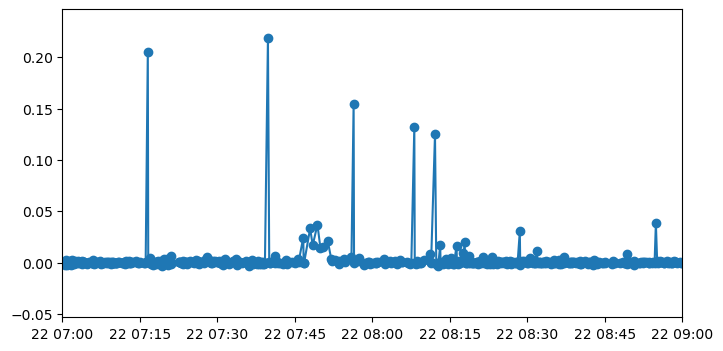

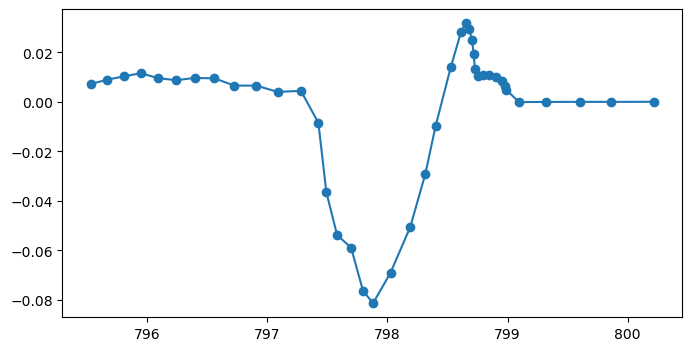

In [18]:
# plot slumping volume
t_keep = ds_filter_v3.t.values[~np.isnan(ds_filter_v3.z.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_filter_v3.sel(t=t_keep)

V = ds_plot.cliff_erosion.sel(t=t_keep)

t1 = pd.Timestamp('2024-12-22 07:00')
t2 = pd.Timestamp('2024-12-22 09:00')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_keep, V, '-o', label='cliff erosion volume [m2]')
ax.set_xlim([t1, t2])

# plot dz ---------
x = ds_plot.x
z = ds_plot.z

slumping = ds_plot.slumping

# select only slumping where true
slumping_times = slumping.t.values[slumping.values]
slumping_idx = np.where(slumping.values)[0]

i_slumping = 0
i = slumping_idx[i_slumping]
x_slumping = x[:, i]
z_slumping = z[:, i]
z_after = z[:, i-1]
dz = z_after - z_slumping

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_slumping, dz, '-o', label='z during slumping')

# calculate time between slumping events
dt = slumping_times[1:]-slumping_times[:-1]
dt_seconds = dt / np.timedelta64(1, 's')
print("Time between slumping events (s):", dt_seconds)


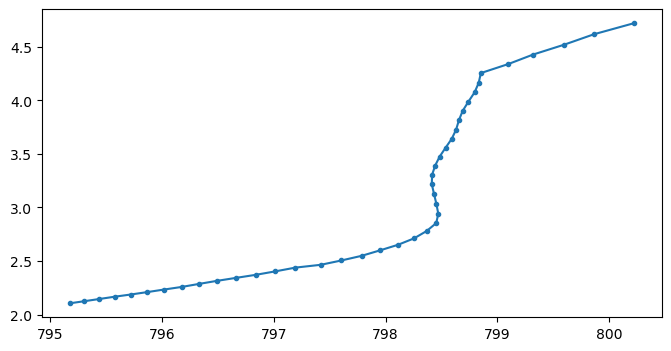

In [19]:
t1 = pd.Timestamp('2024-12-22 07:11')

x = ds_filter_v3.x.sel(t=t1, method='nearest')
z = ds_filter_v3.z.sel(t=t1, method='nearest')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, z, '-o', label=f'profile at {t1}', markersize=3)

In [20]:
# TEMPORAL FILTERING
# Segment-aware rolling stats: window never crosses slumping events.

# Rules for each timestep j (based on centered window [start0, end0)):
# 1) If previous AND next slumping event are both in the centered window: use interval between them.
# 2) Else if only previous slumping event is in the centered window: use 120 samples after that event.
# 3) Else if only next slumping event is in the centered window: use window up to (excluding) that event.
# 4) Else: use standard centered rolling window.

i = 12                  # 5s interval, so 12 [profiles per minute]
window_minutes = 10     # look at 10-minute windows to filter out outliers (foam)
window_length = 12 * window_minutes
n_std_z_pass1 = 2       # number of standard deviations for z filtering
n_std_I = 1             # number of standard deviations for intensity filtering (kept for consistency)

# FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS
x = ds_filter_v3.x  # size (obs_number, t)
z = ds_filter_v3.z
I = ds_filter_v3.intensity
slumping = ds_filter_v3.slumping  # boolean: True where a slumping event starts (between t-1 and t)


def _event_aware_window_bounds(slumping_1d, n_t, window_len):
    """Return start/end indices (end exclusive) for each t without crossing slumping events."""
    half = window_len // 2
    event_idx = np.flatnonzero(np.asarray(slumping_1d, dtype=bool))

    # For each t: nearest previous event index and nearest following event index
    t_idx = np.arange(n_t)

    # Use guarded indexing to avoid out-of-bounds when no previous/next event exists.
    prev_evt = np.full(n_t, -1, dtype=int)
    next_evt = np.full(n_t, n_t, dtype=int)

    if event_idx.size > 0:
        pos_prev = np.searchsorted(event_idx, t_idx, side="right") - 1
        valid_prev = pos_prev >= 0
        prev_evt[valid_prev] = event_idx[pos_prev[valid_prev]]

        pos_next = np.searchsorted(event_idx, t_idx, side="left")
        valid_next = pos_next < event_idx.size
        next_evt[valid_next] = event_idx[pos_next[valid_next]]

    starts = np.zeros(n_t, dtype=int)
    ends = np.zeros(n_t, dtype=int)

    for j in range(n_t):
        # Default centered window (length window_len where possible)
        start0 = max(0, j - half)
        end0 = min(n_t, start0 + window_len)
        if end0 - start0 < window_len:  # shift start if near end, to keep full window length
            start0 = max(0, end0 - window_len)

        has_prev_in_centered = (prev_evt[j] >= start0) and (prev_evt[j] <= j)
        has_next_in_centered = (next_evt[j] < end0) and (next_evt[j] > j)

        if has_prev_in_centered and has_next_in_centered:
            # Preceding and following events in window: use interval between them
            s = prev_evt[j]
            e = next_evt[j]
        elif has_prev_in_centered:
            # Preceding event in window: use 120 samples after that event
            s = prev_evt[j]
            e = min(n_t, s + window_len)
            # Never cross a following event
            if next_evt[j] < e:
                e = next_evt[j]
        elif has_next_in_centered:
            # Following event in window: use window up to (not including) that event
            e = next_evt[j]
            s = max(0, e - window_len)
            # Never cross previous event
            if prev_evt[j] >= 0 and s < prev_evt[j]:
                s = prev_evt[j]
        else:
            # No nearby events: standard centered rolling window
            s = start0
            e = end0

        # Ensure non-empty window
        if e <= s:
            s = max(0, min(j, n_t - 1))
            e = min(n_t, s + 1)

        starts[j] = s
        ends[j] = e

    return starts, ends


def rolling_mean_std_event_aware(da_2d, slumping_1d, window_len):
    """
    Compute mean/std over t for each obs_number using event-aware windows.
    da_2d dims must be ('obs_number', 't'), slumping_1d dims must contain 't'.
    """
    da_2d = da_2d.transpose("obs_number", "t")
    n_obs, n_t = da_2d.shape

    # Align slumping to t and force bool
    s = slumping_1d.reindex(t=da_2d.t, fill_value=False).fillna(False).astype(bool)

    starts, ends = _event_aware_window_bounds(s.values, n_t=n_t, window_len=window_len)

    arr = da_2d.values
    mean_arr = np.full((n_obs, n_t), np.nan, dtype=float)
    std_arr = np.full((n_obs, n_t), np.nan, dtype=float)

    for j in range(n_t):
        w = arr[:, starts[j]:ends[j]]
        mean_arr[:, j] = np.nanmean(w, axis=1)
        std_arr[:, j] = np.nanstd(w, axis=1)
        # if w contains only nans, print the value of j
        if np.isnan(mean_arr[:, j]).all():
            print(f"Warning: all values are NaN in window for t index {j} (time {da_2d.t.values[j]}), window bounds [{starts[j]}, {ends[j]})")

    mean_da = xr.DataArray(mean_arr, dims=("obs_number", "t"), coords={"obs_number": da_2d.obs_number, "t": da_2d.t})
    std_da = xr.DataArray(std_arr, dims=("obs_number", "t"), coords={"obs_number": da_2d.obs_number, "t": da_2d.t})

    return mean_da, std_da


# Filter 1: remove worst outliers using event-aware rolling stats
z_mean, z_std = rolling_mean_std_event_aware(z, slumping, window_length)
I_mean, I_std = rolling_mean_std_event_aware(I, slumping, window_length)

# filter: make z nan where:  |z-z_mean| > 1 cm  &  |z-z_mean| > 2 std  &  |I-I_mean| > 1 std
mask_keep1 = np.abs(z - z_mean) < 0.01 
mask_keep2 = np.abs(z - z_mean) < n_std_z_pass1 * z_std # first pass: > 2std
mask_keep3 = np.abs(I - I_mean) < n_std_I * I_std

z_filtered_v3 = z.where(mask_keep1 | mask_keep2 | mask_keep3)  # keep where either condition is met  
I_filtered_v3 = I.where(mask_keep1 | mask_keep2 | mask_keep3)  

# Re-calculate rolling mean and std of z and I
z_mean2, z_std2 = rolling_mean_std_event_aware(z_filtered_v3, slumping, window_length)
I_mean2, I_std2 = rolling_mean_std_event_aware(I_filtered_v3, slumping, window_length)

# filter: make z nan where |z-z_mean| > 1 cm AND > 2 std
mask_keep1 = np.abs(z_filtered_v3 - z_mean2) < 0.01 
mask_keep2 = np.abs(z_filtered_v3 - z_mean2) < n_std_z_pass2* z_std2 # second pass: > 2std, stricter
mask_keep3 = np.abs(I_filtered_v3 - I_mean2) < n_std_I* I_std2

z_filtered_v3 = z_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3)#.sel(t=t_keep)  # keep where either condition is met
I_filtered_v3 = I_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3)#.sel(t=t_keep)  

# assign filtered values to dataset
ds_filter_v4 = ds_filter_v3.copy(deep=True)  # to avoid modifying ds_filter_v3
ds_filter_v4["z"] = z_filtered_v3
ds_filter_v4["intensity"] = I_filtered_v3


C:\Users\dpoppema\AppData\Local\Temp\ipykernel_4452\2814486935.py:110: RuntimeWarning: Mean of empty slice
  mean_arr[:, j] = np.nanmean(w, axis=1)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\dpoppema\AppData\Local\Temp\ipykernel_4452\2814486935.py:110: RuntimeWarning: Mean of empty slice
  mean_arr[:, j] = np.nanmean(w, axis=1)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\dpoppema\AppData\Local\Temp\ipykernel_4452\2814486935.py:110: RuntimeWarning: Mean of empty slice
  mean_arr[:, j] = np.nanmean(w, axis=1)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: Run

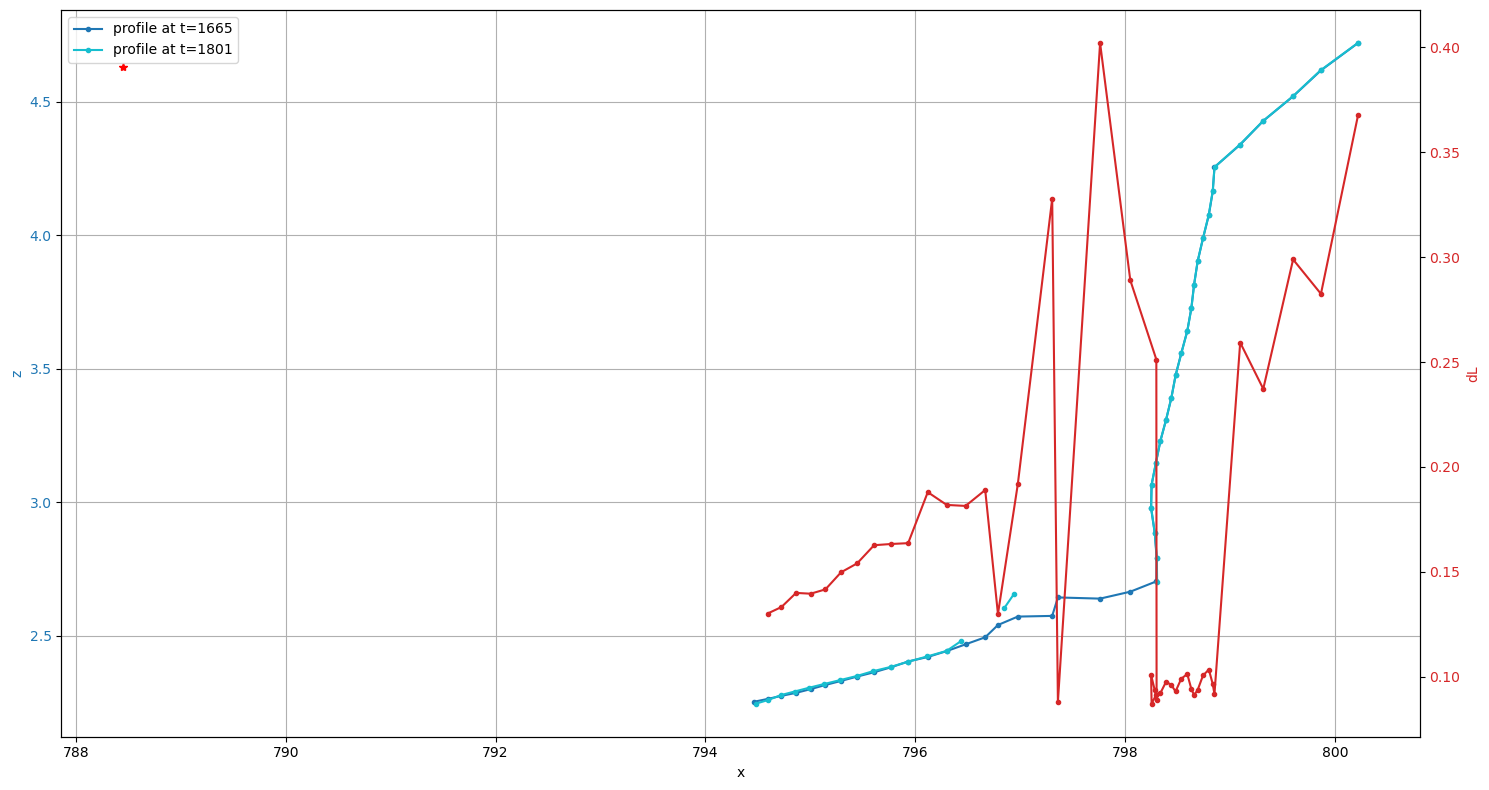

In [21]:
z = ds_filter_v2.x
z1 = z[:,1664:1802]

x_temp = ds_filter_v2.x[:,1665]
z_temp = ds_filter_v2.z[:,1665]
i = 1770
x_temp2 = ds_filter_v2.x[:,i]
z_temp2 = ds_filter_v2.z[:,i]

dx = x_temp[0:-1].values - x_temp[1:].values
dz = z_temp[0:-1].values - z_temp[1:].values
dL = np.sqrt(dx**2 + dz**2)
dx


# make plot with two y-axes, one for z and one for dL
fig, ax1 = plt.subplots(figsize=(15, 8)) 
color = 'tab:blue'
ax1.set_xlabel('x')
ax1.set_ylabel('z', color=color)
ax1.plot(x_temp, z_temp, '-o', label='profile at t=1665', markersize=3, color=color)
ax1.plot(x_temp2, z_temp2, '-o', label='profile at t=1801', markersize=3, color='tab:cyan')
ax1.plot(ds_filter_v2.x_i_local, ds_filter_v2.z_i, '*r')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.set_aspect('equal')
ax1.grid()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('dL', color=color)  # we already handled the x-label with ax1
ax2.plot(x_temp[1:], dL, '-o', label='dx between points', markersize=3, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
ax1.legend(loc='upper left')
plt.show()

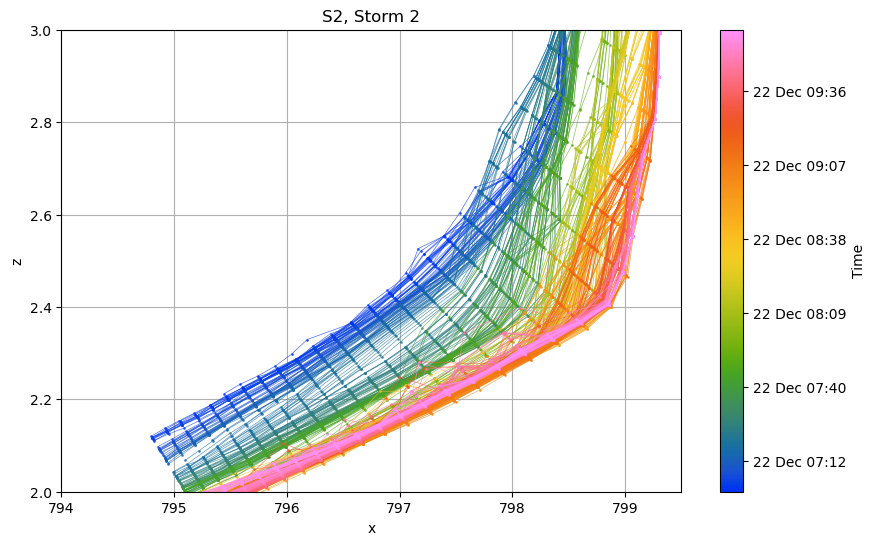

In [22]:

t1 = pd.Timestamp('2024-12-19 18:45') 
t2 = pd.Timestamp('2024-12-19 18:59') 
t1 = pd.Timestamp('2024-12-22 7:00') 
t2 = pd.Timestamp('2024-12-22 10:00') 
#t1 = np.datetime64('2025-01-01T15:00')
#t2 = np.datetime64('2025-01-01T16:00')

ds_plot = ds_filter_v3.sel(t=slice(t1, t2))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t']
step = 1#max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))
x_prev = None

# plot lines on ax 
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    if x_prev is not None:
        if np.nanmax(np.abs(x[mask] - x_prev[mask])) < 0.01:  # skip profiles almost identical to previous one, ignoring NaNs
            continue

    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)
    x_prev = x.copy()
    z_prev = z.copy()

for j in range(0, n_steps, step):
    color = cmap(norm(times_num[j]))
    #ax.plot(ds_plot.x_toe.values[j], ds_plot.z_toe.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    ax.plot(ds_plot.x_crest.values[j], ds_plot.z_crest.values[j], '*', markersize=9, color=color)  # plot crest location for this profile


# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([794, 799.5])
ax.set_ylim([2, 3])

ax.grid()
#ax.set_aspect('equal', adjustable='box')
ax.set_title(f"S{n_lidar}, Storm {n_storm}")

filename = f"Dune profiles with toe -  S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=200)

plt.show()


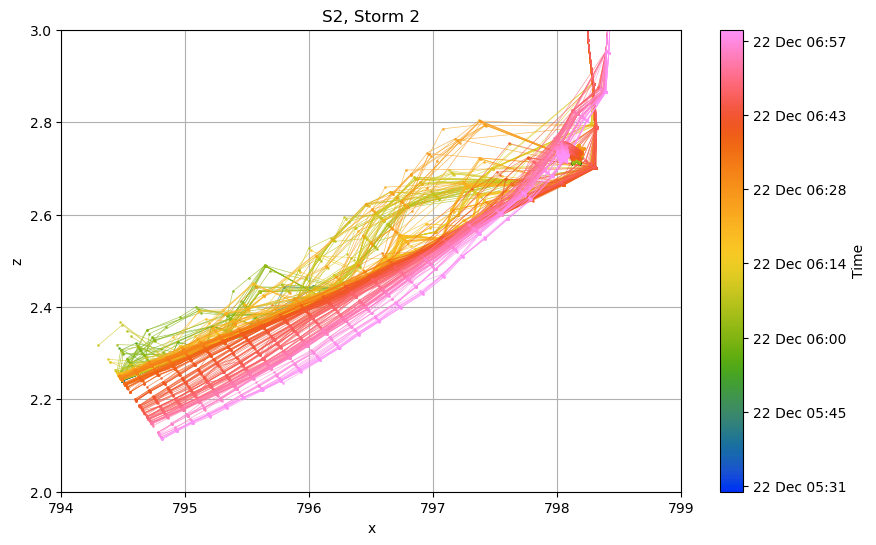

In [23]:
t1 = pd.Timestamp('2024-12-19 18:45') 
t2 = pd.Timestamp('2024-12-19 18:59') 
t1 = pd.Timestamp('2024-12-22 5:30') 
t2 = pd.Timestamp('2024-12-22 7:00') 
#t1 = np.datetime64('2025-01-01T15:00')
#t2 = np.datetime64('2025-01-01T16:00')

ds_plot = ds_filter_v4.sel(t=slice(t1, t2))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t']
step = 1#max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))
x_prev = None

# plot lines on ax 
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    if x_prev is not None:
        if np.nanmax(np.abs(x[mask] - x_prev[mask])) < 0.01:  # skip profiles almost identical to previous one, ignoring NaNs
            continue

    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)
    x_prev = x.copy()
    z_prev = z.copy()

for j in range(0, n_steps, step):
    color = cmap(norm(times_num[j]))
    ax.plot(ds_plot.x_toe.values[j], ds_plot.z_toe.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    ax.plot(ds_plot.x_crest.values[j], ds_plot.z_crest.values[j], '*', markersize=9, color=color)  # plot crest location for this profile


# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([794, 799])
ax.set_ylim([2, 3])

ax.grid()
#ax.set_aspect('equal', adjustable='box')
ax.set_title(f"S{n_lidar}, Storm {n_storm}")

filename = f"Dune profiles with toe -  S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=200)

plt.show()


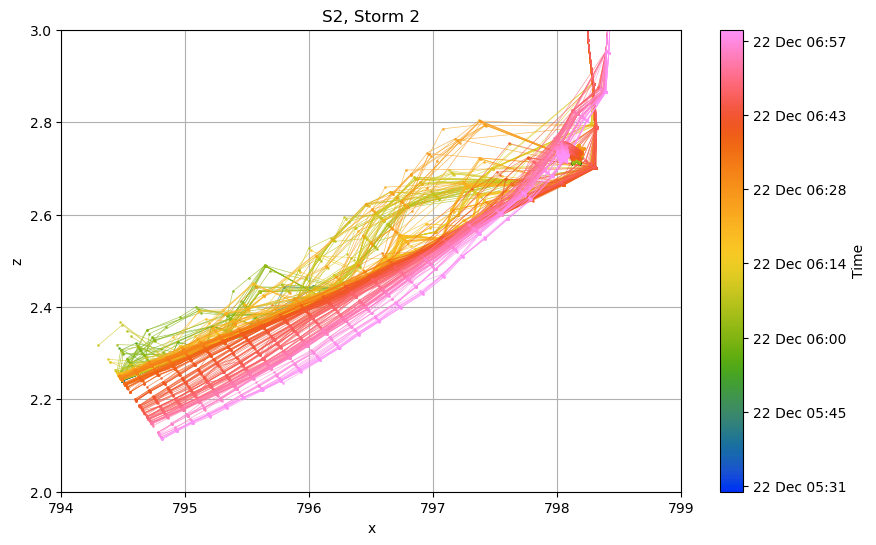

In [24]:
t1 = pd.Timestamp('2024-12-19 18:45') 
t2 = pd.Timestamp('2024-12-19 18:59') 
t1 = pd.Timestamp('2024-12-22 5:30') 
t2 = pd.Timestamp('2024-12-22 7:00') 
#t1 = np.datetime64('2025-01-01T15:00')
#t2 = np.datetime64('2025-01-01T16:00')

ds_plot = ds_filter_v4.sel(t=slice(t1, t2))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t']
step = 1#max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))
x_prev = None

# plot lines on ax 
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    if x_prev is not None:
        if np.nanmax(np.abs(x[mask] - x_prev[mask])) < 0.01:  # skip profiles almost identical to previous one, ignoring NaNs
            continue

    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)
    x_prev = x.copy()
    z_prev = z.copy()

for j in range(0, n_steps, step):
    color = cmap(norm(times_num[j]))
    ax.plot(ds_plot.x_toe.values[j], ds_plot.z_toe.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    ax.plot(ds_plot.x_crest.values[j], ds_plot.z_crest.values[j], '*', markersize=9, color=color)  # plot crest location for this profile


# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([794, 799])
ax.set_ylim([2, 3])

ax.grid()
#ax.set_aspect('equal', adjustable='box')
ax.set_title(f"S{n_lidar}, Storm {n_storm}")

filename = f"Dune profiles with toe -  S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=200)

plt.show()
